# 12b — Geodesy, Wind Direction, and Map Projections

Covers `chap12_coordinate1` through `coordinate6` and `chap12_data1`: DMS/DD
angle conversion, WGS84 reference-ellipsoid parameters (two equivalent
derivations plus a summary table matching MATLAB's `wgs84Ellipsoid`),
a geodetic-to-ECEF worked example (Paris), three world-map projections used
to introduce physical-risk hazard mapping (Mollweide, Lambert conformal
conic, Wiechel), and a wind-direction u/v vector-decomposition compass
diagram.

**Mapping data note:** MATLAB's `landareas.shp` (a Mapping Toolbox built-in)
isn't shipped in this archive, and this environment's network egress blocks
the live Natural Earth downloads `cartopy` normally uses for offline land
data. Land polygons here instead come from the `basemap-data` package
(`pip install basemap basemap-data`), which bundles GSHHS coastline data
directly in the wheel — no runtime download needed. `coordinate4`
(Mollweide) and `coordinate5` (Lambert) use `mpl_toolkits.basemap.Basemap`
directly. `coordinate6` (Wiechel) needed a different approach — see its
section below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.basemap import Basemap
from pyproj import Transformer

DATA_DIR = "../../data"

# House palette (matches the MATLAB init_color.m constants used throughout
# the series).
color_blue    = "#1f77b4"
color_red     = "#d62728"
color_green   = "#2ca02c"
color_black   = "#000000"
color_matlab_darkpurple = "#7E2F8E"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = False


## 1. DMS to decimal degrees (`chap12_coordinate1`)

$50°10'8''$ converted to decimal degrees: $DD = D + M/60 + S/3600$.

In [2]:
D, M, S = 50, 10, 8
DD = D + M / 60 + S / 3600
print(f"{DD:.5f}")


50.16889


## 2. WGS84 ellipsoid parameters (`chap12_coordinate2`)

The WGS84 flattening $f$, squared eccentricity $e^2$, and eccentricity $e$
derived two equivalent ways: directly from the semi-major/semi-minor axes
$a,b$, and from the inverse flattening $1/f = 298.257223563$. Both must
agree (up to the input axes' rounding). We close with a summary table of
the standard WGS84 constants, standing in for MATLAB's `wgs84Ellipsoid`
object display.

In [3]:
a = 6378137.0
b = 6356752.3142
f = (a - b) / a
e2 = (a ** 2 - b ** 2) / a ** 2
e = np.sqrt(e2)
print("From semi-axes a, b:")
print(f"  f   = {f:.9f}")
print(f"  e^2 = {e2:.9f}")
print(f"  e   = {e:.9f}")
print()

g = 298.257223563
f_inv = 1 / g
e2_inv = 2 * f_inv - f_inv ** 2
e_inv = np.sqrt(2 * f_inv - f_inv ** 2)
print("From inverse flattening 1/f = 298.257223563:")
print(f"  f   = {f_inv:.9f}")
print(f"  e^2 = {e2_inv:.9f}")
print(f"  e   = {e_inv:.9f}")


From semi-axes a, b:
  f   = 0.003352811
  e^2 = 0.006694380
  e   = 0.081819191

From inverse flattening 1/f = 298.257223563:
  f   = 0.003352811
  e^2 = 0.006694380
  e   = 0.081819191


In [4]:
# Summary table equivalent to MATLAB's `disp(wgs84Ellipsoid)` object display
wgs84_summary = pd.Series({
    "Name": "World Geodetic System 1984",
    "LengthUnit": "meter",
    "SemimajorAxis": a,
    "SemiminorAxis": b,
    "InverseFlattening": g,
    "Eccentricity": e_inv,
}, name="wgs84Ellipsoid")
display(wgs84_summary.to_frame())


,wgs84Ellipsoid
Name,World Geodetic System 1984
LengthUnit,meter
SemimajorAxis,6378137.0
SemiminorAxis,6356752.3142
InverseFlattening,298.257224
Eccentricity,0.081819


## 3. Geodetic to ECEF: Paris (`chap12_coordinate3`)

Converts Paris's geodetic coordinates
($48°51'24''\mathrm{N}$, $2°21'07''\mathrm{E}$, $h=67.4\,\mathrm{m}$) to
Earth-Centered-Earth-Fixed (ECEF) Cartesian coordinates, both by the
explicit formula

$$N(\varphi) = \frac{a}{\sqrt{1-e^2\sin^2\varphi}}, \qquad
x=(N+h)\cos\varphi\cos\lambda,\ \ y=(N+h)\cos\varphi\sin\lambda,\ \
z=(N(1-e^2)+h)\sin\varphi$$

and via `pyproj`'s WGS84 geographic-to-ECEF transform (`EPSG:4979` &#8594;
`EPSG:4978`), the equivalent of MATLAB's `geodetic2ecef`, as a cross-check.

In [5]:
a = 6378137.0
e2 = 0.006694380

lat_deg = 48 + 51 / 60 + 24 / 3600
lon_deg = 2 + 21 / 60 + 7 / 3600
h = 67.4
print(f"phi (deg) = {lat_deg:.5f}, lambda (deg) = {lon_deg:.5f}")

varphi = np.radians(lat_deg)
lam = np.radians(lon_deg)
print(f"phi (rad) = {varphi:.10f}, lambda (rad) = {lam:.10f}")

N = a / np.sqrt(1 - e2 * np.sin(varphi) ** 2)
print(f"N(phi) = {N:.5f} m")

x = (N + h) * np.cos(varphi) * np.cos(lam)
y = (N + h) * np.cos(varphi) * np.sin(lam)
z = (N * (1 - e2) + h) * np.sin(varphi)
print(f"ECEF (m):  x={x:.3f}  y={y:.3f}  z={z:.3f}")
print(f"ECEF (km): x={x/1000:.3f}  y={y/1000:.3f}  z={z/1000:.3f}")

transformer = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
x2, y2, z2 = transformer.transform(lon_deg, lat_deg, h)
print(f"pyproj check (km): x={x2/1000:.3f}  y={y2/1000:.3f}  z={z2/1000:.3f}")


phi (deg) = 48.85667, lambda (deg) = 2.35194
phi (rad) = 0.8527096949, lambda (rad) = 0.0410491744
N(phi) = 6390278.68672 m
ECEF (m):  x=4200954.295  y=172542.630  z=4780136.976
ECEF (km): x=4200.954  y=172.543  z=4780.137
pyproj check (km): x=4200.954  y=172.543  z=4780.137


## Shared land-polygon data

Extracted once from the bundled GSHHS ('l'ow resolution) coastline data,
via a plate-carree (`'cyl'`) `Basemap` instance whose projected coordinates
equal raw (lon, lat) — so `.landpolygons[i].boundary` recovers the
unprojected vertex arrays directly, without a network download.

In [6]:
_cyl = Basemap(projection="cyl", resolution="l",
               llcrnrlon=-180, urcrnrlon=180, llcrnrlat=-90, urcrnrlat=90)
_cyl.drawcoastlines(linewidth=0)
_cyl.fillcontinents()
LAND_POLYGONS_LONLAT = [p.boundary for p in _cyl.landpolygons]
plt.close("all")
print(f"{len(LAND_POLYGONS_LONLAT)} land polygons extracted")


295 land polygons extracted


## 4. World map — Mollweide projection (`chap12_coordinate4`)

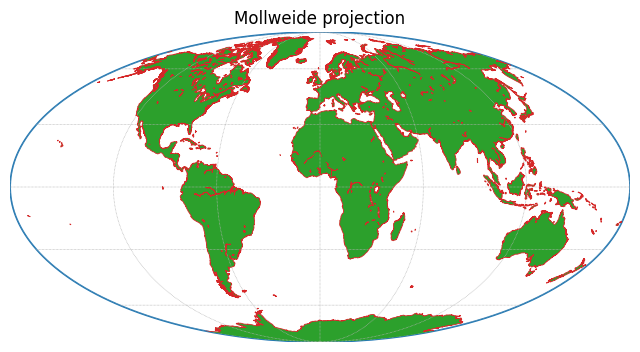

In [7]:
fig = plt.figure(figsize=(8, 5))
m = Basemap(projection="moll", lon_0=0, resolution="l")
m.drawmapboundary(color=color_blue, linewidth=1.2)
m.drawparallels(np.arange(-90, 91, 30), linewidth=0.5, color="0.7")
m.drawmeridians(np.arange(-180, 181, 60), linewidth=0.5, color="0.7")
m.fillcontinents(color=color_green, lake_color="white")
m.drawcoastlines(color=color_red, linewidth=0.6)
plt.title("Mollweide projection")
plt.show()


## 5. World map — Lambert conformal conic projection (`chap12_coordinate5`)

The source calls `axesm('lambert', ...)` with no explicit standard
parallels or map limits. MATLAB's default extent/parallels for an
unconfigured Lambert conformal conic axes aren't reproducible without the
Mapping Toolbox itself, so — since the exercise's point is a qualitative
comparison of projection *families*, not a specific regional map — we use
representative standard parallels ($20°\mathrm{N}$, $60°\mathrm{N}$)
centered on $40°\mathrm{N}$, disclosed here as a simplifying assumption.

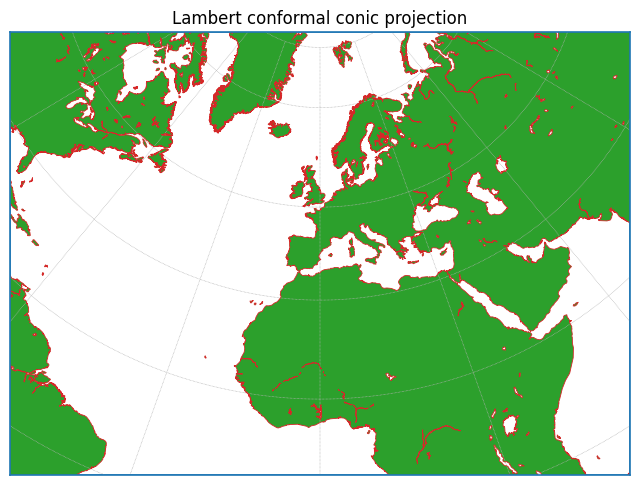

In [8]:
fig = plt.figure(figsize=(8, 6))
m = Basemap(projection="lcc", lon_0=0, lat_0=40, lat_1=20, lat_2=60,
            width=1.4e7, height=1.0e7, resolution="l")
m.drawmapboundary(color=color_blue, linewidth=1.2)
m.drawparallels(np.arange(-90, 91, 20), linewidth=0.5, color="0.7")
m.drawmeridians(np.arange(-180, 181, 30), linewidth=0.5, color="0.7")
m.fillcontinents(color=color_green, lake_color="white")
m.drawcoastlines(color=color_red, linewidth=0.6)
plt.title("Lambert conformal conic projection")
plt.show()


## 6. World map — Wiechel projection (`chap12_coordinate6`)

The Wiechel projection (H. Wiechel, 1879) is a pseudoazimuthal, equal-area
projection with semicircular meridians arranged in a pinwheel around the
pole — obtained from the polar Lambert azimuthal equal-area projection by
an area-preserving angular warp. It isn't implemented in PROJ (confirmed
absent from pyproj's full `get_proj_operations_map()`, 184 entries) or in
Basemap, so we implement its closed-form polar-aspect equations directly:

$$x = R\big(\sin\lambda\cos\varphi - (1-\sin\varphi)\cos\lambda\big), \qquad
y = -R\big(\cos\lambda\cos\varphi + (1-\sin\varphi)\sin\lambda\big)$$

with $\varphi,\lambda$ latitude/longitude in radians and $R$ the sphere
radius (verified self-consistent: $x^2+y^2 = 2R^2(1-\sin\varphi)$, the
same radial equal-area function as the polar Lambert azimuthal
projection). This canonical form is centered on the North Pole — the
"typically centered at a pole" aspect the projection is normally shown in
— rather than attempting to match an unspecified MATLAB default center.
Per the projection's documented ~65° usable radius (data far from the pole
piles up and self-overlaps), we plot only the Northern Hemisphere
($\varphi>0$).

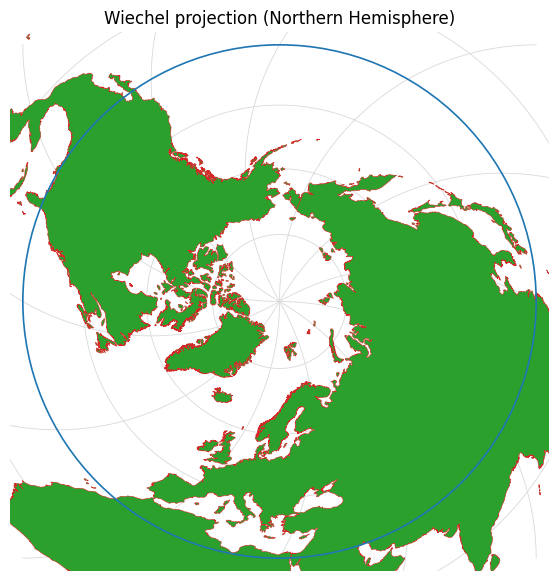

In [9]:
def wiechel_forward(lon_deg, lat_deg, R=1.0):
    lam = np.radians(lon_deg)
    phi = np.radians(lat_deg)
    x = R * (np.sin(lam) * np.cos(phi) - (1 - np.sin(phi)) * np.cos(lam))
    y = -R * (np.cos(lam) * np.cos(phi) + (1 - np.sin(phi)) * np.sin(lam))
    return x, y


fig, ax = plt.subplots(figsize=(7, 7))

# Graticule: parallels every 15 deg (10 deg) as pinwheel-warped circles,
# meridians every 30 deg as the characteristic semicircular arcs.
lam_grid = np.linspace(-180, 180, 361)
for lat in range(15, 91, 15):
    x, y = wiechel_forward(lam_grid, np.full_like(lam_grid, lat, dtype=float))
    ax.plot(x, y, color="0.85", linewidth=0.6, zorder=1)
phi_grid = np.linspace(0, 90, 181)
for lon in range(-180, 180, 30):
    x, y = wiechel_forward(np.full_like(phi_grid, lon, dtype=float), phi_grid)
    ax.plot(x, y, color="0.85", linewidth=0.6, zorder=1)

for poly in LAND_POLYGONS_LONLAT:
    lon, lat = poly[:, 0], poly[:, 1]
    if np.nanmax(lat) < 0:
        continue  # entirely southern hemisphere: outside the plotted cap
    x, y = wiechel_forward(lon, lat)
    ax.fill(x, y, color=color_green, edgecolor=color_red, linewidth=0.4, zorder=2)

frame = mpatches.Circle((0, 0), 1.0, fill=False, edgecolor=color_blue, linewidth=1.2, zorder=3)
ax.add_patch(frame)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Wiechel projection (Northern Hemisphere)")
plt.show()


## 7. Wind-direction compass diagram (`chap12_data1`)

A worked example decomposing a wind vector into its $u$ (East-West) and $v$
(North-South) components. Meteorological convention: wind direction $\phi$
is measured clockwise from North and describes where the wind blows
*from*, so the velocity vector itself points the opposite way:

$$u = -w\sin\phi, \qquad v = -w\cos\phi$$

Here $\phi=240°$ (a south-westerly wind) at unit speed $w=1$.

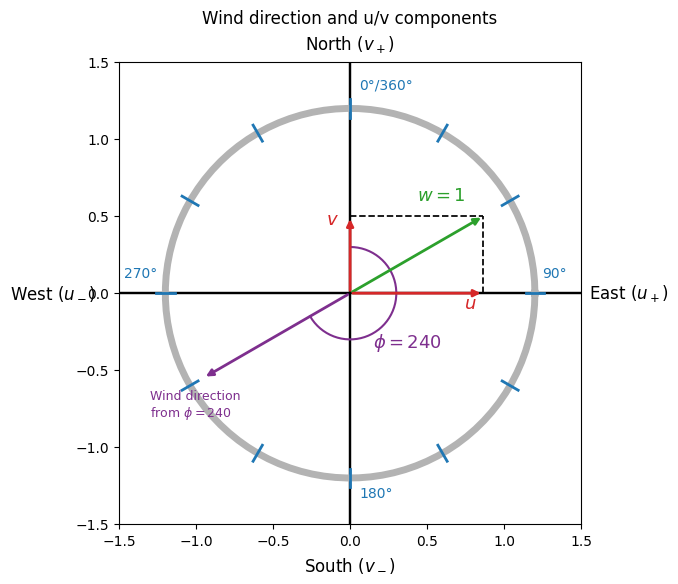

=== Wind Component Calculations ===
Example: Wind FROM 240° at 1.00 m/s
u-component: 0.866 m/s
v-component: 0.500 m/s
Verification: sqrt(u^2 + v^2) = 1.000 m/s


In [10]:
wind_direction_deg = 240
wind_speed = 1.0
phi = np.radians(wind_direction_deg)
u = -wind_speed * np.sin(phi)
v = -wind_speed * np.cos(phi)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([-1.5, 1.5], [0, 0], "-", color=color_black, linewidth=1.75)
ax.plot([0, 0], [-1.5, 1.5], "-", color=color_black, linewidth=1.75)

theta_circle = np.linspace(0, 2 * np.pi, 100)
radius_circle = 1.20
ax.plot(radius_circle * np.cos(theta_circle), radius_circle * np.sin(theta_circle),
        "-", color="0.7", linewidth=5)

for angle_deg in range(0, 360, 30):
    math_angle = np.radians(90 - angle_deg)
    x_in = radius_circle * 0.95 * np.cos(math_angle)
    y_in = radius_circle * 0.95 * np.sin(math_angle)
    x_out = radius_circle * 1.05 * np.cos(math_angle)
    y_out = radius_circle * 1.05 * np.sin(math_angle)
    ax.plot([x_in, x_out], [y_in, y_out], "-", color=color_blue, linewidth=2.0)

ax.text(1.55, 0, "East ($u_+$)", fontsize=12, ha="left", va="center")
ax.text(-1.65, 0, "West ($u_-$)", fontsize=12, ha="right", va="center")
ax.text(0, 1.55, "North ($v_+$)", fontsize=12, ha="center", va="bottom")
ax.text(0, -1.70, "South ($v_-$)", fontsize=12, ha="center", va="top")

ax.text(0.06, 1.325, "0°/360°", fontsize=10, color=color_blue)
ax.text(1.25, 0.10, "90°", fontsize=10, color=color_blue)
ax.text(0.06, -1.325, "180°", fontsize=10, color=color_blue)
ax.text(-1.47, 0.10, "270°", fontsize=10, color=color_blue)

ax.annotate("", xy=(u, v), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=color_green, lw=2))
ax.annotate("", xy=(u, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=color_red, lw=2))
ax.annotate("", xy=(0, v), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=color_red, lw=2))

ax.text(0.90 * u, -0.10, "$u$", fontsize=13, color=color_red, ha="center")
ax.text(-0.07, 0.90 * v, "$v$", fontsize=13, color=color_red, ha="right")
ax.plot([u, u], [0, v], "--", color=color_black, linewidth=1.25)
ax.plot([0, u], [v, v], "--", color=color_black, linewidth=1.25)
ax.text(0.5 * u, v + 0.10, f"$w = {wind_speed:g}$", fontsize=13, color=color_green)

theta_arc = np.linspace(np.pi / 2, np.pi / 2 - phi, 50)
r_arc = 0.3
ax.plot(r_arc * np.cos(theta_arc), r_arc * np.sin(theta_arc), "-",
        color=color_matlab_darkpurple, linewidth=1.5)
ax.text(0.15, -0.35, f"$\phi = {wind_direction_deg}$", fontsize=13,
        color=color_matlab_darkpurple)

ax.annotate("", xy=(-u * 1.10, -v * 1.10), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=color_matlab_darkpurple, lw=2))
ax.text(-1.3, -0.80, f"Wind direction\nfrom $\phi = {wind_direction_deg}$",
        fontsize=9, color=color_matlab_darkpurple)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal")
ax.set_title("Wind direction and u/v components", pad=28)
plt.show()

print("=== Wind Component Calculations ===")
print(f"Example: Wind FROM {wind_direction_deg}\u00b0 at {wind_speed:.2f} m/s")
print(f"u-component: {u:.3f} m/s")
print(f"v-component: {v:.3f} m/s")
print(f"Verification: sqrt(u^2 + v^2) = {np.sqrt(u**2 + v**2):.3f} m/s")
